In [6]:
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

2026-03-04 16:18:20.502510: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-04 16:18:21.415609: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-04 16:18:24.417328: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [19]:
DATA_DIR = "./pictures_training/"
IMG_SIZE = (480, 640)

In [20]:
def load_images_and_labels(folder):
    paths = Path(folder).glob("*.jpg")
    imgs = []
    labels = []

    for p in paths:
        img = cv2.imread(str(p))
        imgs.append(img)
        label = str(p).split("_")[-1].split(".")[0]
        labels.append(int(label))

    return imgs, labels

In [21]:
imgs, labels = load_images_and_labels(DATA_DIR)

In [22]:
len(imgs)

186

In [23]:
len(labels)

186

In [27]:
np.array(imgs).shape

(186, 480, 640, 3)

In [28]:
def preprocess_images(imgs, target_size=IMG_SIZE):
  out = [cv2.resize(img, target_size) for img in imgs]
  out = np.asarray(out) / 255
  return out

In [29]:
X = preprocess_images(imgs)

In [30]:
y = np.asarray(labels)

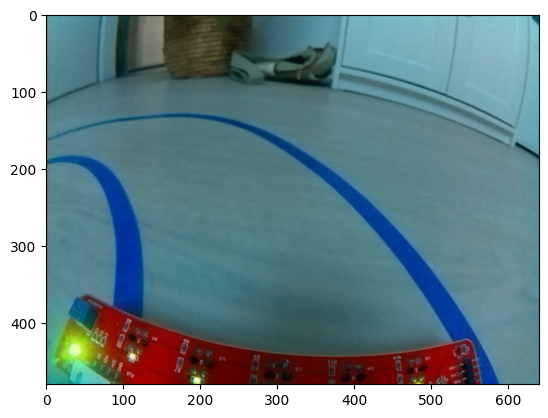

In [31]:
plt.imshow(X[0, :, :, ::-1])

In [32]:
def show_examples(images, labels, n=8, title="Beispiele"):
    n = min(n, len(images))
    idx = np.random.choice(len(images), n, replace=False)
    cols = 4
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(12, 3*rows))
    for i, j in enumerate(idx, 1):
        plt.subplot(rows, cols, i)
        img = images[j]
        if img.dtype != np.uint8:
            img = (np.clip(img, 0, 1) * 255).astype(np.uint8)
        plt.imshow(img[:,:,::-1]); plt.title(f"Label: {labels[j]}"); plt.axis("off")
    plt.suptitle(title); plt.tight_layout(); plt.show()

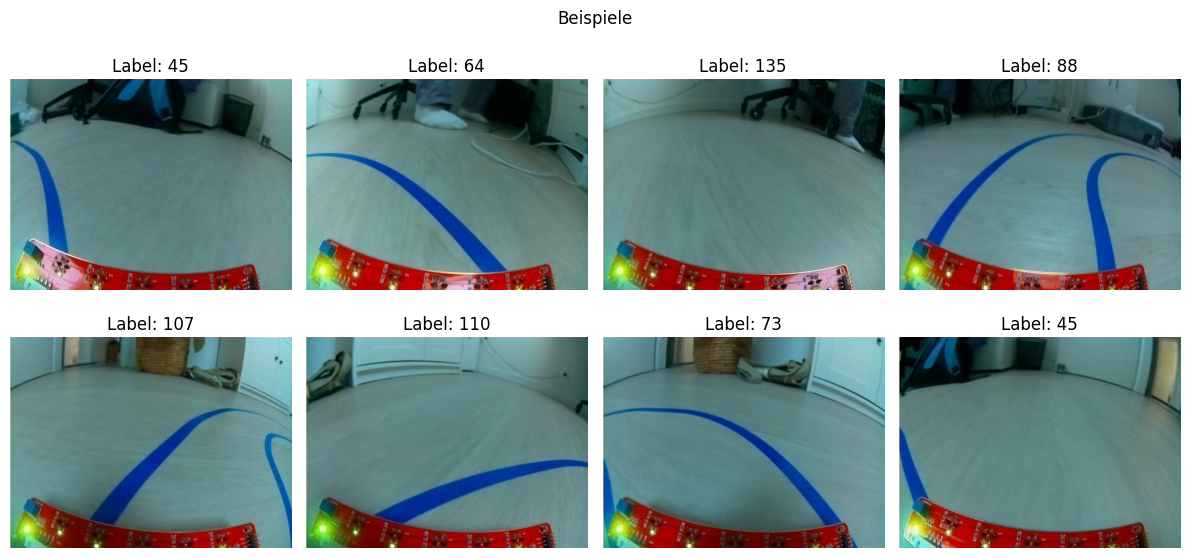

In [33]:
show_examples(X, y)

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
def mirror_images(images, labels):
    X_m = [img[:,::-1,:] for img in images]
    y_m = [180 - label for label in labels]

    return X_m, y_m

In [36]:
X_train_m, y_train_m = mirror_images(X_train, y_train)
X_train_pool = np.concatenate([X_train, X_train_m])
y_train_pool = np.concatenate([y_train, y_train_m])

In [37]:
X_train_pool.shape

(296, 480, 640, 3)

(array([10.,  1.,  5.,  4.,  1.,  3.,  5.,  1.,  1.,  7.]),
 array([ 45.,  54.,  63.,  72.,  81.,  90.,  99., 108., 117., 126., 135.]),
 <BarContainer object of 10 artists>)

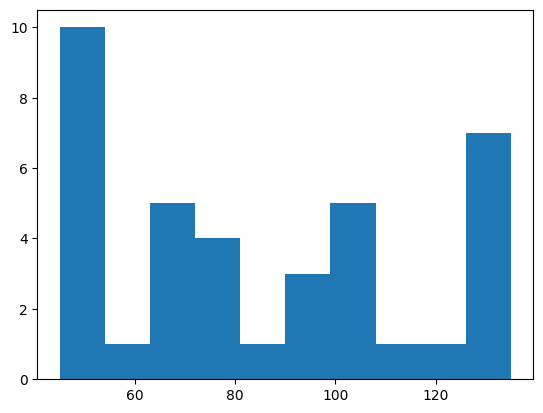

In [38]:
plt.hist(y_test)

In [39]:
size = X_train_pool.shape[1:]

In [40]:
model = tf.keras.Sequential(name='Fahrspurerkennung')
model.add(layers.Resizing(480,640))
# Convolution Layers 
# elu: Expenential Linear Unit, similar to leaky Relu 
model.add(layers.Conv2D(24, (5, 5), strides=(2, 2), input_shape=(100, 200, 3), activation='elu')) 
model.add(layers.Conv2D(36, (5, 5), strides=(2, 2), activation='elu'))
model.add(layers.Conv2D(48, (5, 5), strides=(2, 2), activation='elu'))
model.add(layers.Conv2D(64, (3, 3), activation='elu')) 
model.add(layers.Dropout(0.2)) # more robustness 
model.add(layers.Conv2D(64, (3, 3), activation='elu')) 
# Fully Connected Layers 
model.add(layers.Flatten()) 
model.add(layers.Dropout(0.2)) # more robustness 
model.add(layers.Dense(100, activation='elu')) 
model.add(layers.Dense(50, activation='elu')) 
model.add(layers.Dense(10, activation='elu'))
# Output Layer: turning angle
model.add(layers.Dense(1)) 

/home/peter/.python3.11.venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1772637771.377856     658 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6071 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2070 SUPER, pci bus id: 0000:65:00.0, compute capability: 7.5


In [41]:
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(X_train_pool, y_train_pool, epochs=10, batch_size=32, validation_data=(X_test, y_test), verbose=1)

Epoch 1/10


2026-03-04 16:23:12.177387: I external/local_xla/xla/service/service.cc:163] XLA service 0x74cf40004d20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-04 16:23:12.177428: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 2070 SUPER, Compute Capability 7.5
2026-03-04 16:23:12.320019: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-04 16:23:12.865522: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
2026-03-04 16:23:15.972994: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,64,55,75]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,48,57,77]{3,2,1,0}, f32[64,48,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target=

 1/10 ━━━━━━━━━━━━━━━━━━━━ 4:01 27s/step - loss: 8864.7422 - mae: 88.5804

I0000 00:00:1772637814.707262    1645 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 6647.9516 - mae: 73.5818

2026-03-04 16:23:37.037785: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[8,64,55,75]{3,2,1,0}, u8[0]{0}) custom-call(f32[8,48,57,77]{3,2,1,0}, f32[64,48,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-03-04 16:23:37.138485: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[8,64,53,73]{3,2,1,0}, u8[0]{0}) custom-call(f32[8,64,55,75]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForwa

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 6456.1014 - mae: 72.1268   

2026-03-04 16:23:52.191821: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[6,64,55,75]{3,2,1,0}, u8[0]{0}) custom-call(f32[6,48,57,77]{3,2,1,0}, f32[64,48,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-03-04 16:23:52.288022: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[6,64,53,73]{3,2,1,0}, u8[0]{0}) custom-call(f32[6,64,55,75]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForwa

10/10 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - loss: 4729.4507 - mae: 59.0317 - val_loss: 1251.3008 - val_mae: 28.5571
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - loss: 1364.6156 - mae: 31.0307 - val_loss: 978.5320 - val_mae: 27.2089
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - loss: 1239.0880 - mae: 30.6266 - val_loss: 1050.4781 - val_mae: 26.9081
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - loss: 1074.4160 - mae: 27.9221 - val_loss: 985.4051 - val_mae: 26.4365
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - loss: 1050.6996 - mae: 27.7514 - val_loss: 931.5076 - val_mae: 26.4676
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - loss: 968.6716 - mae: 27.1199 - val_loss: 881.9672 - val_mae: 25.6628
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - loss: 838.6447 - mae: 25.0986 - val_loss: 650.6255 - val_mae: 22.3398
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - loss: 560.7366 - mae: 19.3759 - val_loss: 1755.0602 - val_mae: 36.3892
Epoch 9/10
10

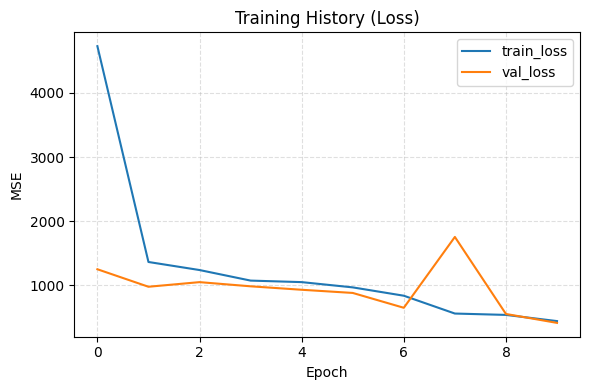

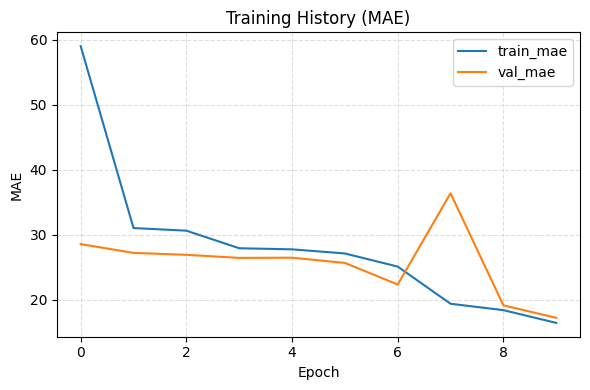

In [42]:
# History-Plots
plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.title("Training History (Loss)")
plt.legend(); plt.grid(True, linestyle="--", alpha=0.4); plt.tight_layout(); plt.show()

plt.figure(figsize=(6,4))
plt.plot(history.history["mae"], label="train_mae")
plt.plot(history.history["val_mae"], label="val_mae")
plt.xlabel("Epoch"); plt.ylabel("MAE"); plt.title("Training History (MAE)")
plt.legend(); plt.grid(True, linestyle="--", alpha=0.4); plt.tight_layout(); plt.show()

In [45]:
y_pred = model.predict(X_test).ravel()
error = abs(y_test - y_pred)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


In [46]:
error

array([ 4.16379547, 12.36636353,  2.66046143, 15.56001282,  7.78975677,
       32.59486389,  4.95645142, 18.33500671, 37.69228363,  8.0861969 ,
        6.83550262, 28.34253693, 40.30847168, 26.0151062 , 25.22434998,
       12.16519928, 14.08146667, 40.69277954, 22.02729797, 12.06167603,
       16.92123413, 26.98274994,  2.42510223, 24.03128052,  4.74373627,
       13.41799164, 15.05570984, 17.09064484,  9.32472229, 35.40385437,
       10.06897736,  7.09635925, 11.68670654,  1.10240173, 21.70587158,
       21.54296875, 13.45275116, 29.97855377])

In [47]:
np.argmax(error)

np.int64(17)

69 85.69278


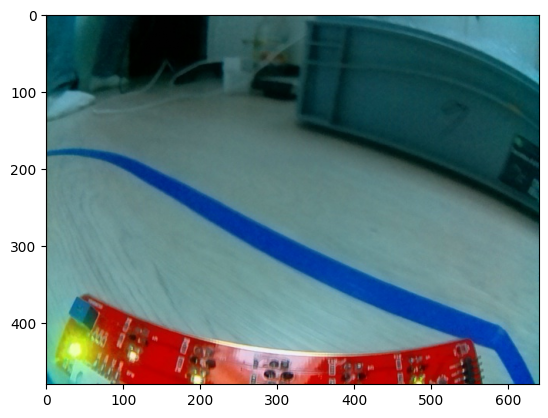

In [50]:
plt.imshow(X_test[17, :, :, ::-1])
print(y_train[17], y_pred[17])

In [51]:
model.save("model_peter.keras")

In [52]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open("PiCar_model.tflite", "wb") as f:
  f.write(tflite_model)

INFO:tensorflow:Assets written to: /tmp/tmpptb7p05s/assets


INFO:tensorflow:Assets written to: /tmp/tmpptb7p05s/assets


Saved artifact at '/tmp/tmpptb7p05s'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 480, 640, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  128442443368400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128442443370896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128442443368592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128442443372048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128442443371664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128442443372624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128442443372432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128442443373200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128442443373392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128442443369936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12844244337416

W0000 00:00:1772638121.020711     658 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1772638121.020764     658 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-03-04 16:28:41.021176: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpptb7p05s
2026-03-04 16:28:41.022093: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-03-04 16:28:41.022105: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpptb7p05s
I0000 00:00:1772638121.030114     658 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
2026-03-04 16:28:41.031488: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-03-04 16:28:41.193725: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpptb7p05s
2026-03-04 16:28:41.212228: I tensorflow/cc/saved_model/loader.cc:471] SavedModel 

In [ ]:
#Für Pi:
interpreter = tflite.Interpreter(model_path="/home/pi/Desktop/git/c2c_Phase2/Software/live_model_fp32.tflite")
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
interpreter.allocate_tensors()
img = np.expand_dims(img, axis=0)
interpreter.set_tensor(input_details[0]['index'], img)
interpreter.invoke()
output_data = interpreter.get_tensor(output_details[0]['index'])
int(output_data)